# Eddy Kinetic Energy Monthly

## U and V anomalies

In [1]:
import xarray as xr
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.patches as mpatches
from tqdm import tqdm

In [2]:
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

def anomaly(data):
    """Compute anomalies by removing the seasonal cycle (monthly climatology)."""
    clim = seasonality(data)
    anom = data.groupby('time.month') - clim
    return anom
    

In [3]:
ssh = xr.open_dataset('/work/bk1450/b383184/Amazon/Mercator/data/variables_c/tracers/SSH_1993-01c.nc')
ssh = ssh.compute()

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'sossheig' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


In [9]:
u =  xr.open_zarr('U_m_0_7m.zarr').compute()
u = u.rename({'time_counter':'time'})
print(u)

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 264, y: 499, x: 1260)
Coordinates:
    nav_lat  (y, x) float32 3MB -9.95 -9.95 -9.95 -9.95 ... 29.95 29.95 29.95
    nav_lon  (y, x) float32 3MB -94.96 -94.88 -94.79 ... 9.805 9.889 9.972
  * time     (time) datetime64[ns] 2kB 1993-01-01 1993-02-01 ... 2014-12-01
  * x        (x) float64 10kB 2.306e+03 2.307e+03 ... 3.564e+03 3.565e+03
  * y        (y) float64 4kB 1.375e+03 1.376e+03 ... 1.872e+03 1.873e+03
Data variables:
    U        (time, y, x) float64 1GB -0.1345 -0.1377 -0.1375 ... nan nan nan


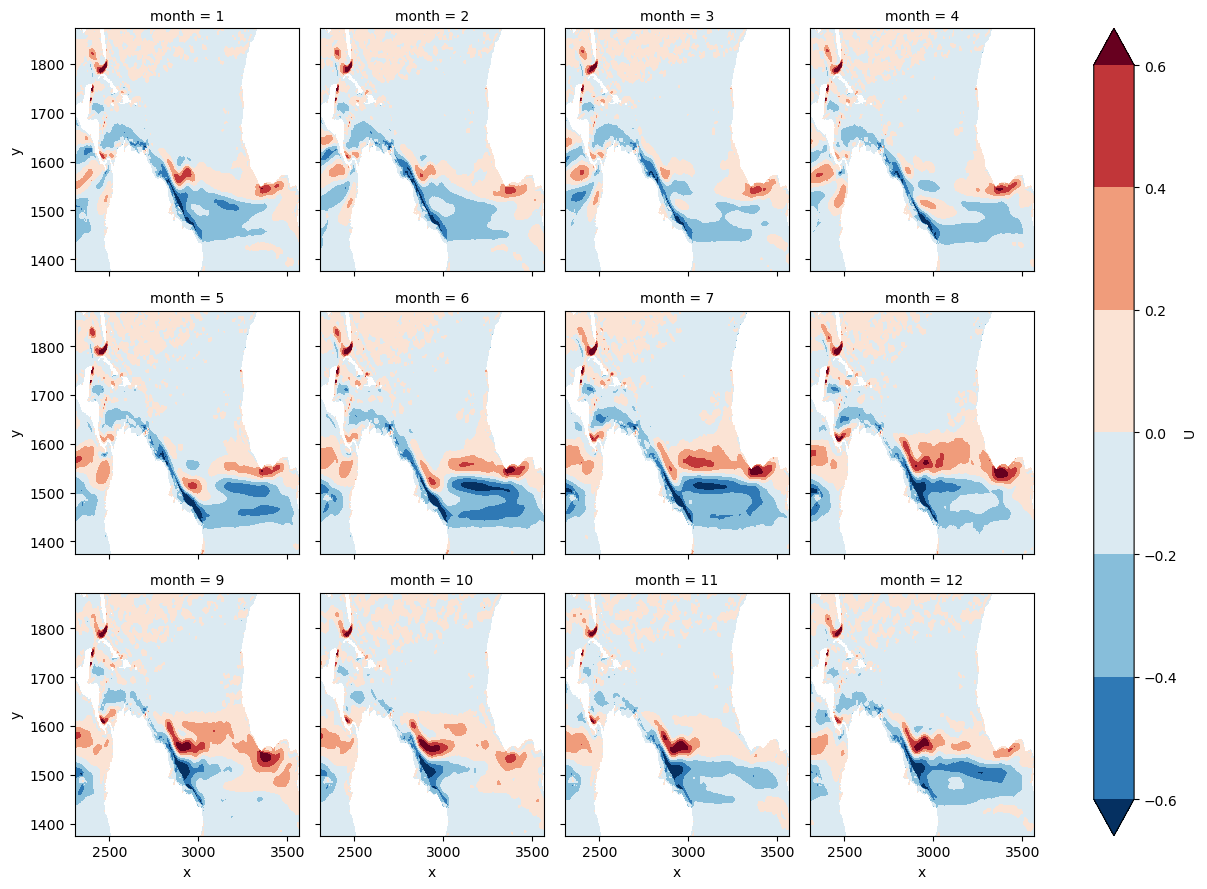

In [5]:
u_clim = seasonality(u)
u_clim.U.plot.contourf(
    x='x',y='y',col="month", col_wrap=4,robust=True)

In [6]:
u_anom = anomaly(u)
u_anom

<xarray.Dataset> Size: 1GB
Dimensions:  (y: 499, x: 1260, time: 264)
Coordinates:
    nav_lat  (y, x) float32 3MB -9.95 -9.95 -9.95 -9.95 ... 29.95 29.95 29.95
    nav_lon  (y, x) float32 3MB -94.96 -94.88 -94.79 ... 9.805 9.889 9.972
  * time     (time) datetime64[ns] 2kB 1993-01-01 1993-02-01 ... 2014-12-01
  * x        (x) float64 10kB 2.306e+03 2.307e+03 ... 3.564e+03 3.565e+03
  * y        (y) float64 4kB 1.375e+03 1.376e+03 ... 1.872e+03 1.873e+03
    month    (time) int64 2kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    U        (time, y, x) float64 1GB -0.06551 -0.0691 -0.06941 ... nan nan nan

In [7]:
v =  xr.open_zarr('V_m_0_7m.zarr').compute()
v = v.rename({'time_counter':'time'})
v

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 264, y: 499, x: 1260)
Coordinates:
    nav_lat  (y, x) float32 3MB -9.909 -9.909 -9.909 ... 29.98 29.98 29.98
    nav_lon  (y, x) float32 3MB -95.0 -94.92 -94.83 -94.75 ... 9.764 9.847 9.93
  * time     (time) datetime64[ns] 2kB 1993-01-01 1993-02-01 ... 2014-12-01
  * x        (x) float64 10kB 2.306e+03 2.307e+03 ... 3.564e+03 3.565e+03
  * y        (y) float64 4kB 1.375e+03 1.376e+03 ... 1.872e+03 1.873e+03
Data variables:
    V        (time, y, x) float64 1GB -0.0422 -0.03297 -0.02451 ... nan nan nan

In [8]:
v_anom = anomaly(v)
v_anom

<xarray.Dataset> Size: 1GB
Dimensions:  (y: 499, x: 1260, time: 264)
Coordinates:
    nav_lat  (y, x) float32 3MB -9.909 -9.909 -9.909 ... 29.98 29.98 29.98
    nav_lon  (y, x) float32 3MB -95.0 -94.92 -94.83 -94.75 ... 9.764 9.847 9.93
  * time     (time) datetime64[ns] 2kB 1993-01-01 1993-02-01 ... 2014-12-01
  * x        (x) float64 10kB 2.306e+03 2.307e+03 ... 3.564e+03 3.565e+03
  * y        (y) float64 4kB 1.375e+03 1.376e+03 ... 1.872e+03 1.873e+03
    month    (time) int64 2kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    V        (time, y, x) float64 1GB -0.02581 -0.01796 -0.009458 ... nan nan

## Local Seasonal circulation in the upper 0-7m 

In [13]:
mesh = xr.open_dataset("/work/bk1450/b383184/Amazon/Mercator/data/Hgr_cmesh.nc").isel(t=0).compute()
mesh

<xarray.Dataset> Size: 70MB
Dimensions:       (y: 499, x: 1260, z: 50)
Dimensions without coordinates: y, x, z
Data variables: (12/21)
    nav_lon       (y, x) float32 3MB -95.0 -94.92 -94.83 ... 9.764 9.847 9.93
    nav_lat       (y, x) float32 3MB -9.95 -9.95 -9.95 ... 29.95 29.95 29.95
    nav_lev       (z) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
    time_counter  float64 8B 0.0
    glamt         (y, x) float32 3MB -95.0 -94.92 -94.83 ... 9.764 9.847 9.93
    glamu         (y, x) float32 3MB -94.96 -94.88 -94.79 ... 9.805 9.889 9.972
    ...            ...
    e1f           (y, x) float64 5MB 9.128e+03 9.128e+03 ... 8.028e+03 8.028e+03
    e2t           (y, x) float64 5MB 9.127e+03 9.127e+03 ... 7.847e+03 7.845e+03
    e2u           (y, x) float64 5MB 9.127e+03 9.127e+03 ... 7.846e+03 7.845e+03
    e2v           (y, x) float64 5MB 9.128e+03 9.128e+03 ... 7.843e+03 7.841e+03
    e2f           (y, x) float64 5MB 9.128e+03 9.128e+03 ... 7.842e+03 7.841e+03
    ff            (y, x) float64 5MB -2.51e-05 -2.51e-05 ... 7.288e-05 7.288e-05
Attributes:
    file_name:            mesh_hgr.nc
    TimeStamp:            03/02/2016 10:24:55 -0000
    Unlimited_Dimension:  t

In [43]:
 # Interpolate to the centers
U_ = seasonality((u.U.shift(x=1) + u.U)*0.5)
V_ = seasonality((v.V.shift(y=1) + v.V)*0.5)

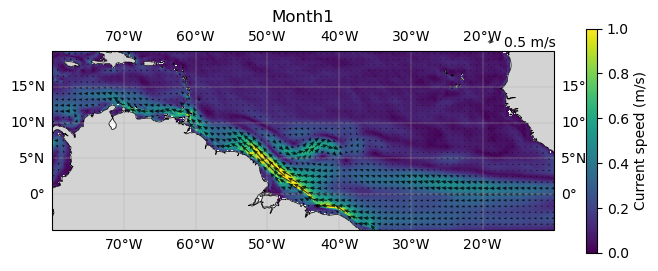

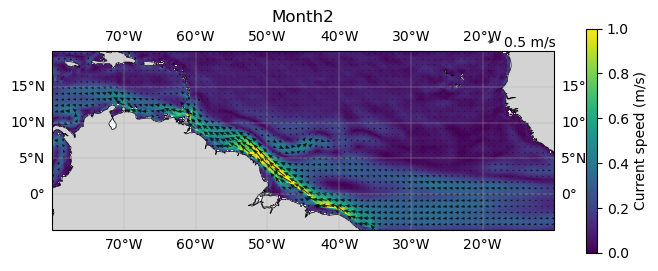

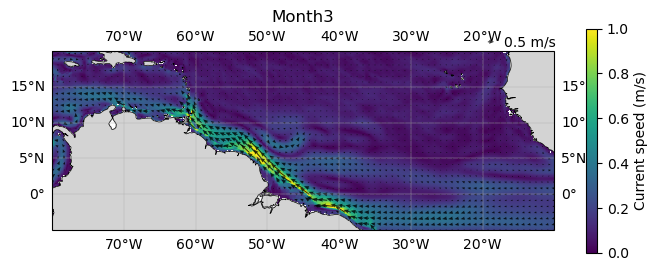

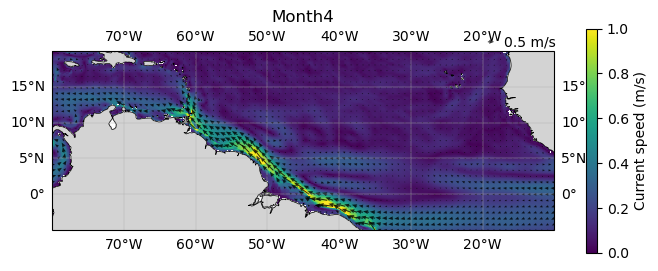

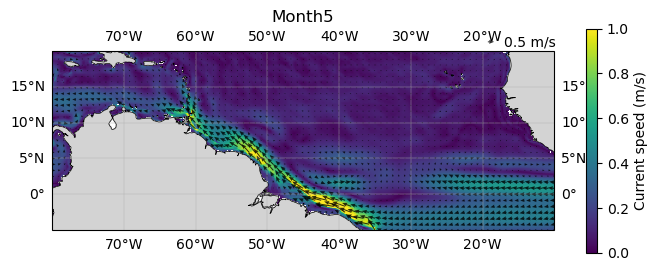

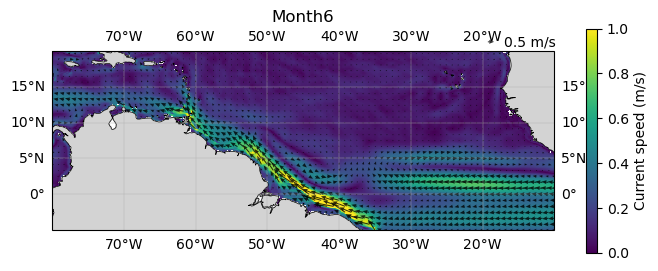

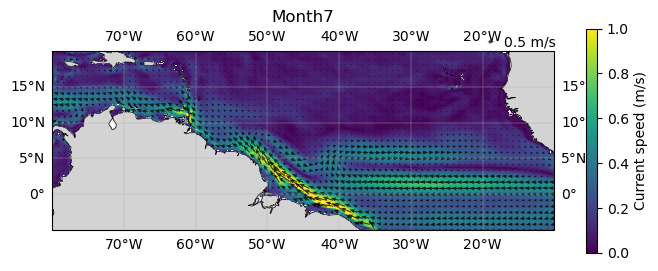

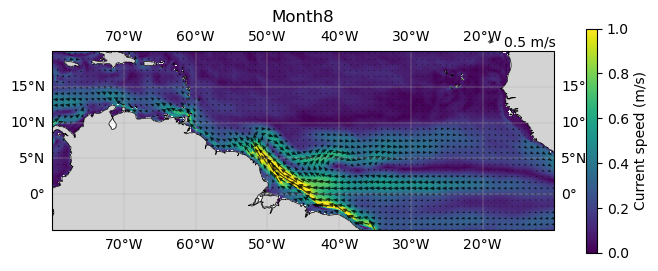

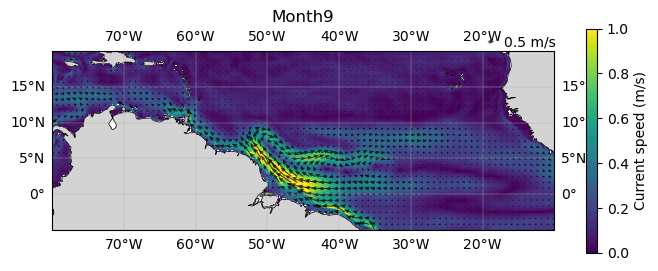

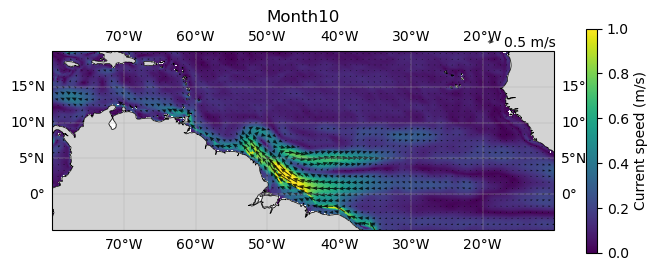

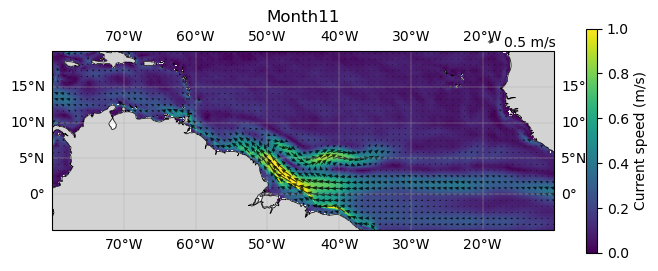

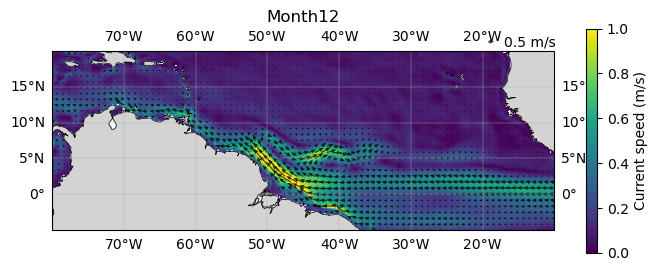

In [49]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
    
# ── 2. T-point coordinates from mesh ────────────────────
lon_T = mesh["glamt"].values             # (499, 1260)
lat_T = mesh["gphit"].values
    
for ii in range(1,13):
    #1 select the month
    U_season = U_.sel(month=ii).values
    V_season = V_.sel(month=ii).values

    # ── 4. Mask land (NaN stays NaN from the averaging) ─────
    speed = np.sqrt(U_season**2 + V_season**2)
    
    # ── 5. Subsample for readable arrows ────────────────────
    s = 10   # every 15th point — tune for your figure size
    lon_s   = lon_T[::s, ::s]
    lat_s   = lat_T[::s, ::s]
    U_s     = U_season[::s, ::s]
    V_s     = V_season[::s, ::s]
    speed_s = speed[::s, ::s]
    
    # ── 6. Plot ─────────────────────────────────────────────
    fig, ax = plt.subplots(
        figsize=(7, 3.5),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )
    ax.set_extent([-80, -10, -5, 20], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, color="lightgray")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    
    # Optional: pcolormesh of speed underneath
    pcm = ax.pcolormesh(
        lon_T, lat_T, speed,
        cmap="viridis",          # or 'YlOrRd', 'viridis'
        vmin=0, vmax=1.0,
        transform=ccrs.PlateCarree(),
        shading="auto"
    )
    plt.colorbar(pcm, ax=ax, label="Current speed (m/s)", shrink=0.7)
    
    # Quiver
    q = ax.quiver(
        lon_s, lat_s, U_s, V_s,
        scale=40,                    # ← tune: smaller = longer arrows
        width=0.002,
        headwidth=4,
        transform=ccrs.PlateCarree(),
        color="k",
        alpha=0.8
    )
    ax.quiverkey(q, 0.88, 1.05, 0.5, "0.5 m/s", labelpos="E")
    
    ax.gridlines(draw_labels=True, linewidth=0.3)
    ax.set_title(f"Month{ii}")
    plt.tight_layout()
    # plt.savefig("currents.png", dpi=150, bbox_inches="tight")
    plt.show()

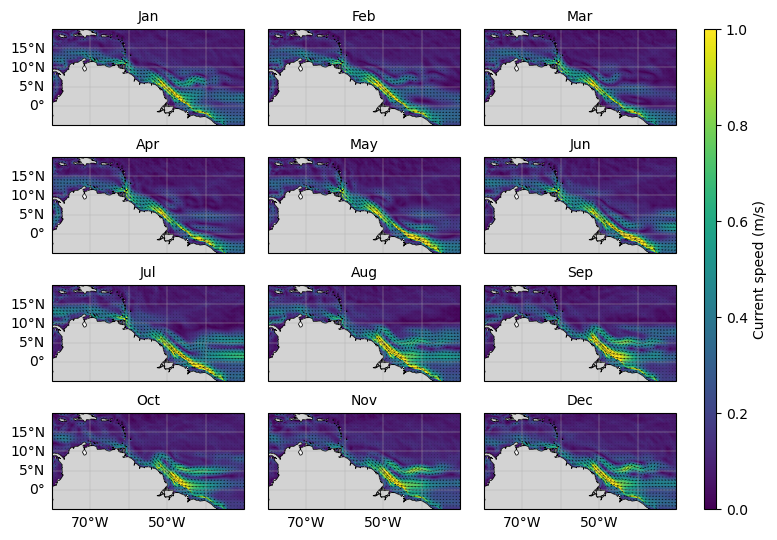

In [80]:
from cartopy.mpl.geoaxes import GeoAxes
extent = [-80, -30, -5, 20]
fig = plt.figure(figsize=(10*0.8, 10*0.8))

# Panel geometry — tune these
ncols, nrows = 3, 4
pw, ph = 0.27, 0.12        # panel width/height as fraction of figure
x0, y0 = 0.03, 0.05          # bottom-left origin
hgap, vgap = 0, 0.04      # horizontal/vertical gaps
cbar_pad = 0.02

axes = []
for row in range(nrows):
    for col in range(ncols):
        x = x0 + col * (pw + hgap)
        y = y0 + (nrows - 1 - row) * (ph + vgap)
        ax = fig.add_axes([x, y, pw, ph], projection=proj)
        axes.append(ax)

for ii, ax in enumerate(axes):
    U_m = U_all[ii]
    V_m = V_all[ii]
    speed = np.hypot(U_m, V_m)

    ax.set_extent(extent, crs=proj)
    ax.add_feature(land, color="lightgray")
    ax.add_feature(coast, linewidth=0.5)

    pcm = ax.pcolormesh(
        lon_T, lat_T, speed,
        cmap="viridis", vmin=0, vmax=1.0,
        transform=proj, shading="auto",
    )

    ax.quiver(
        lon_s, lat_s,
        U_m[::s, ::s], V_m[::s, ::s],
        scale=30, width=0.002, headwidth=4,
        transform=proj, color="k", alpha=0.8,
    )

    ax.set_title(month_names[ii], fontsize=10)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3)
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (ii % 3 == 0)
    gl.bottom_labels = (ii >= 9)

# Colorbar in remaining space on the right
cax = fig.add_axes([x0 + ncols * (pw + hgap) + cbar_pad, y0, 0.015, nrows * (ph + vgap) - vgap])
fig.colorbar(pcm, cax=cax, label="Current speed (m/s)")

# fig.suptitle("Monthly Mean 0-7m Currents", fontsize=14, y=0.97)
# plt.savefig("currents_monthly.png", dpi=300, bbox_inches="tight")
plt.show()

### Monthly Mean Eddy Kinetic energy

In [28]:
U_T = ((u_anom.U.shift(x=1) + u_anom.U)*0.5)
V_T = ((v_anom.V.shift(y=1) + v_anom.V)*0.5)

In [23]:
U_V = xr.Dataset(
    data_vars={
        'u_anom': (('time','lat','lon'), U_T.data),
        'v_anom': (('time','lat', 'lon'), V_T.data),
    },
    coords={
        'time':U_T.time.data,
        'lat':ssh.nav_lat.isel(x=0).data,
        'lon':ssh.nav_lon.isel(y=0).data,
    }
    )
U_V

<xarray.Dataset> Size: 3GB
Dimensions:  (time: 264, lat: 499, lon: 1260)
Coordinates:
  * time     (time) datetime64[ns] 2kB 1993-01-01 1993-02-01 ... 2014-12-01
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
Data variables:
    u_anom   (time, lat, lon) float64 1GB nan -0.06731 -0.06925 ... nan nan nan
    v_anom   (time, lat, lon) float64 1GB nan nan nan nan ... nan nan nan nan

In [49]:
EKE_m = (U_V.u_anom**2  + U_V.v_anom**2 )/2
# EKE_m.drop_encoding().to_netcdf('EKE_monthly.nc')

### NBC area from Dippner 2024
NBC turns and gets deflected in the following areas

* lon=slice(-55,-51), lat=slice(7,10) --> Dippner
* lon=slice(-55,-40), lat=slice(2,10) --> Me
* ARP Area 15N-0N, 65W-49W -- liang et al., 2020

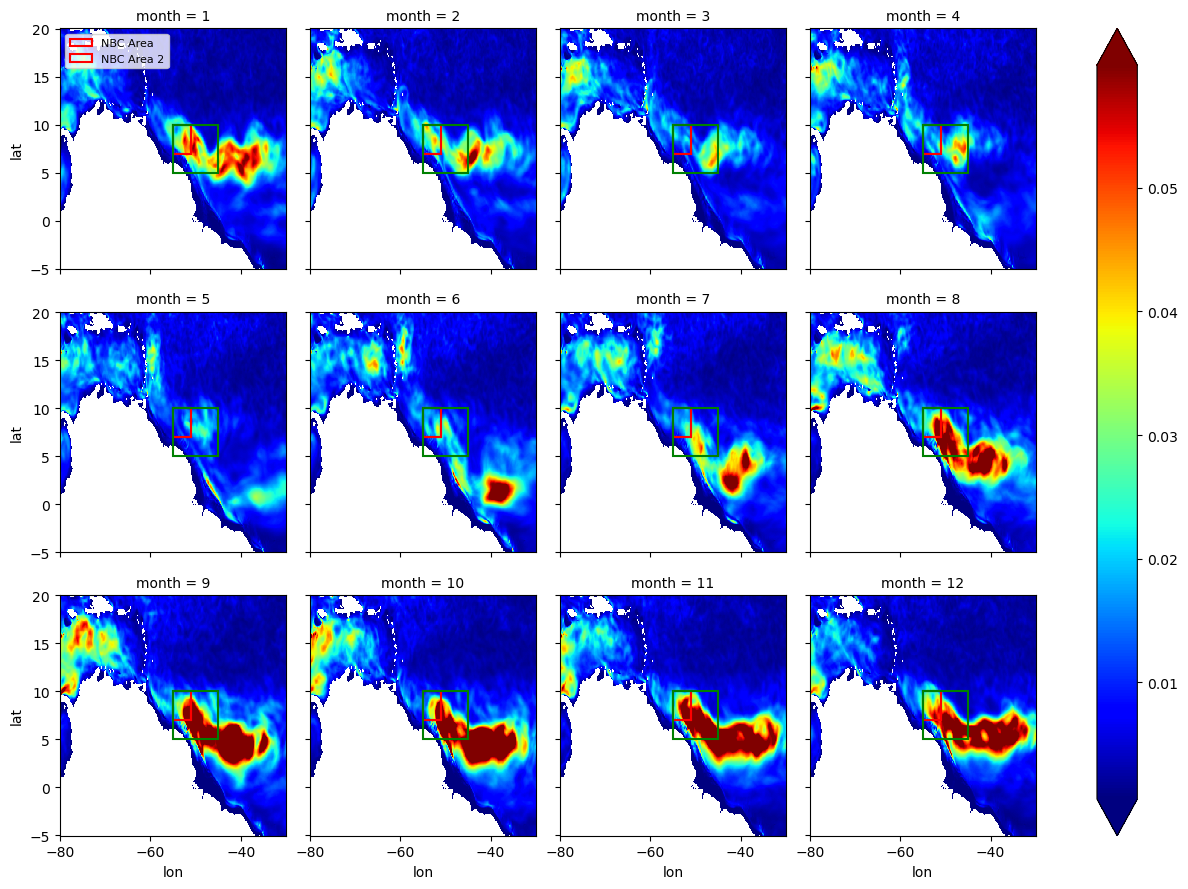

In [50]:
g = seasonality(EKE_m).sel(lat=slice(-5, 20), lon=slice(-80, -30))\
    .plot(x='lon',y='lat',col='month',col_wrap=4,robust=True,cmap='jet')

for ax in g.axs.flat:
    rect = mpatches.Rectangle(
        xy=(-55, 7),
        width=4,
        height=3,
        linewidth=1.5,
        edgecolor='red',
        facecolor='none'
    )
    ax.add_patch(rect)

    rect2 = mpatches.Rectangle(
        xy=(-55, 5),
        width=10,
        height=5,
        linewidth=1.5,
        edgecolor='green',
        facecolor='none'
    )
    ax.add_patch(rect) 
    ax.add_patch(rect2)

# Add legend to the first subplot (optional)
g.axs.flat[0].legend(['NBC Area','NBC Area 2'], loc='upper left', fontsize=8)

# plt.tight_layout()
plt.show()

* Idea, too much EKE in the Area favours retention of particles and Caribean Pathways (OND), while less EKE favours dispersal of particles to the tropics (AMJ)

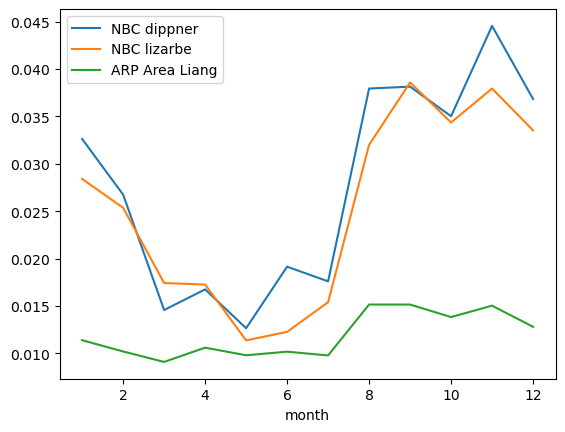

In [53]:
seasonality(EKE_m).sel(lon=slice(-55,-51), lat=slice(7,10)).mean(dim=('lon','lat')).plot(label='NBC dippner')
seasonality(EKE_m).sel(lon=slice(-55,-40), lat=slice(5,10)).mean(dim=('lon','lat')).plot(label='NBC lizarbe')
seasonality(EKE_m).sel(lon=slice(-65,-49), lat=slice(0,15)).mean(dim=('lon','lat')).plot(label='ARP Area Liang')

plt.legend()